In [1]:
import keras
from keras import layers

inputs = layers.Input(shape=(224, 224, 3))
x = layers.ZeroPadding2D(padding=3)(inputs)
x = layers.Conv2D(64, 7, strides=2) (x)
x = layers.BatchNormalization(epsilon=1e-5) (x)
x = layers.Activation('relu') (x)
x = layers.ZeroPadding2D(padding=1) (x)
x = layers.MaxPooling2D(3, strides=2) (x)

2026-04-14 12:19:18.437618: I tensorflow/core/util/port.cc:113] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2026-04-14 12:19:18.485763: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-14 12:19:18.485807: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-14 12:19:18.487248: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-14 12:19:18.496927: I tensorflow/core/platform/cpu_feature_guar

In [2]:
def build_stack(x):
    x = residual_stack(x, 3, 64, first_stride = 1)
    for blocks, filters in [ (4,128), (6,256), (3,512)]:
        x = residual_stack(x, blocks, filters)
    return x
    
    

def residual_stack(x, blocks, filters, first_stride=2):
    x = residual_block(x, filters, first_stride = first_stride, conv_skip=True)
    for _ in range(1, blocks):
        x = residual_block(x, filters , first_stride = 1, conv_skip=False)
    return x
    
        

In [3]:
def residual_block(x, filters, first_stride=1, conv_skip=False):
    skip_conn = x
    x = layers.Conv2D(filters=filters, kernel_size=1, strides=first_stride)(x)
    x = layers.BatchNormalization(epsilon=1e-5)(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters=filters, kernel_size=3, padding='same') (x)
    x = layers.BatchNormalization(epsilon=1e-5)(x)
    x = layers.Activation('relu')(x)

    x = layers.Conv2D(filters=filters*4, kernel_size=1)(x)
    x = layers.BatchNormalization(epsilon=1e-5)(x)

    if conv_skip == True:
        skip_conn = layers.Conv2D(filters=filters*4, kernel_size=1,
                                  strides=first_stride) (skip_conn)
        skip_conn = layers.BatchNormalization(epsilon=1e-5) (skip_conn)

    x = layers.Add()([skip_conn , x])
    x = layers.Activation('relu') (x)
    return x
    
        

    
    
    

In [4]:
x = build_stack(x)

In [5]:
x = layers.GlobalAveragePooling2D() (x)
outputs = layers.Dense( 1000, activation='softmax') (x)


In [6]:
model = keras.Model(inputs, outputs)
model.summary()


Model: "model"
__________________________________________________________________________________________________
 Layer (type)                Output Shape                 Param #   Connected to                  
 input_1 (InputLayer)        [(None, 224, 224, 3)]        0         []                            
                                                                                                  
 zero_padding2d (ZeroPaddin  (None, 230, 230, 3)          0         ['input_1[0][0]']             
 g2D)                                                                                             
                                                                                                  
 conv2d (Conv2D)             (None, 112, 112, 64)         9472      ['zero_padding2d[0][0]']      
                                                                                                  
 batch_normalization (Batch  (None, 112, 112, 64)         256       ['conv2d[0][0]']          

In [7]:
from PIL import Image

dog_png = Image.open('images/dog.png')

In [8]:
import numpy as np

In [9]:
dog_array= np.array(dog_png)
dog_array.shape

(224, 224, 3)

In [13]:
from keras.applications import resnet

model = resnet50.ResNet50(weights='imagenet')

prep_img = resnet50.preprocess_input(dog_array)

predictions = model.predict(prep_img[np.newaxis, :])

1/1 [==============================] - 1s 880ms/step


In [12]:
resnet50.decode_predictions(predictions)

[[('n02099712', 'Labrador_retriever', 0.38618293),
  ('n02099601', 'golden_retriever', 0.08966987),
  ('n02100735', 'English_setter', 0.04207099),
  ('n02106166', 'Border_collie', 0.0376261),
  ('n02101388', 'Brittany_spaniel', 0.030699115)]]

In [29]:
from keras.applications import inception_v3
from keras.utils import load_img

dog_png = load_img('images/dog.png', target_size=(299,299))
incep_dog_png = inception_v3.preprocess_input(np.array(dog_png))

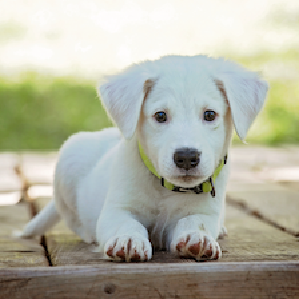

In [30]:
display(dog_png)

In [31]:
inception = keras.applications.InceptionV3()
predictions = inception.predict( incep_dog_png[ np.newaxis, : ] )
inception_v3.decode_predictions( predictions )
decoded = inception_v3.decode_predictions(predictions)



1/1 [==============================] - 1s 1s/step


In [32]:
decoded

[[('n02104029', 'kuvasz', 0.13908954),
  ('n02099712', 'Labrador_retriever', 0.07776205),
  ('n02106166', 'Border_collie', 0.07184517),
  ('n02111500', 'Great_Pyrenees', 0.06638832),
  ('n02099601', 'golden_retriever', 0.028437138)]]